# Cross-Modal GradCAM for MRL CLIP

This Notebool allow you generate the GradCAM to Visualize the model's focus on regions in the image based on a **Text Query** (input sentence), and compare the change in focus as the dimensionality changes according to **Matryoshka Representation Learning (MRL)**.

**Note:** Running this notebook requires the installation of the following libraries: `transformers`, `grad-cam`, `matplotlib`, `pillow`, `requests`.

In [9]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests

# point to the folder that contains the model code
sys.path.append('../ai-worker/')
from model import MRL_CrossModal_Model
from transformers import CLIPProcessor

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

%matplotlib inline
%config InlineBackend.figure_format='retina'

## 1. Initialize the Model and Load Checkpoint

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Initialize MRL Cross-Modal Model (default CLIP ViT-B/32)
mrl_model = MRL_CrossModal_Model().to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Load the checkpoint if it exists
ckpt_path = "../ai-worker/checkpoints/mrl_v3_best.pt"
if os.path.exists(ckpt_path):
     mrl_model.load_state_dict(torch.load(ckpt_path, map_location=device))
     print("Loaded checkpoint successfully!")

mrl_model.eval()

Using device: cpu


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 31050.43it/s]


Loaded checkpoint successfully!


MRL_CrossModal_Model(
  (clip): CLIPModel(
    (text_model): CLIPTextModel(
      (embeddings): CLIPTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
            (mlp): CLIPMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=2048, out_features=512, b

## 2. Wrap model to compute Cosine Similarity (purpose of GradCAM)

In [11]:
class CLIPSimilarityWrapper(torch.nn.Module):
    def __init__(self, model, text_embeds, mrl_dim=768):
        super().__init__()
        self.model = model
        self.text_embeds = text_embeds
        self.mrl_dim = mrl_dim
        
    def forward(self, images):
        # Extract image features (Note: Gradient will flow through this section)
        img_embeds = self.model.extract_image_features(images, dim=self.mrl_dim)
        
        # Normalize cosine similarity
        img_embeds = torch.nn.functional.normalize(img_embeds, dim=-1)
        txt_embeds = torch.nn.functional.normalize(self.text_embeds, dim=-1)
        
        # Calculate similarity (Dot product of 2 normalized vectors)
        # The result returned has the shape [batch, 1], and GradCAM will automatically understand this as the point to maximize.
        sim = (img_embeds * txt_embeds).sum(dim=-1, keepdim=True)
        return sim

## 3. Declare Image and Text Query

In [15]:
# load img from your device (local path)
img_url = r"D:\Pre-thesis\Thesis Dataset-20260617T002927Z-3-002\Thesis Dataset\data_images\11971.jpg"
image = Image.open(img_url).convert("RGB")

# text query for GradCAM
text_query = "a white fila shoe"

# Image and text preprocessing
inputs = processor(text=[text_query], images=image, return_tensors="pt", padding=True).to(device)

# take the text embedding from the model (no gradient needed)
with torch.no_grad():
    full_text_embeds = mrl_model.extract_text_features(inputs.input_ids, inputs.attention_mask)

# Prepare the RGB image (224x224) normalized to 0-1 for heatmap overlay
rgb_img = np.array(image.resize((224, 224)), dtype=np.float32) / 255.0

## 4. Configure GradCAM for Vision Transformer (ViT) and draw Heatmap

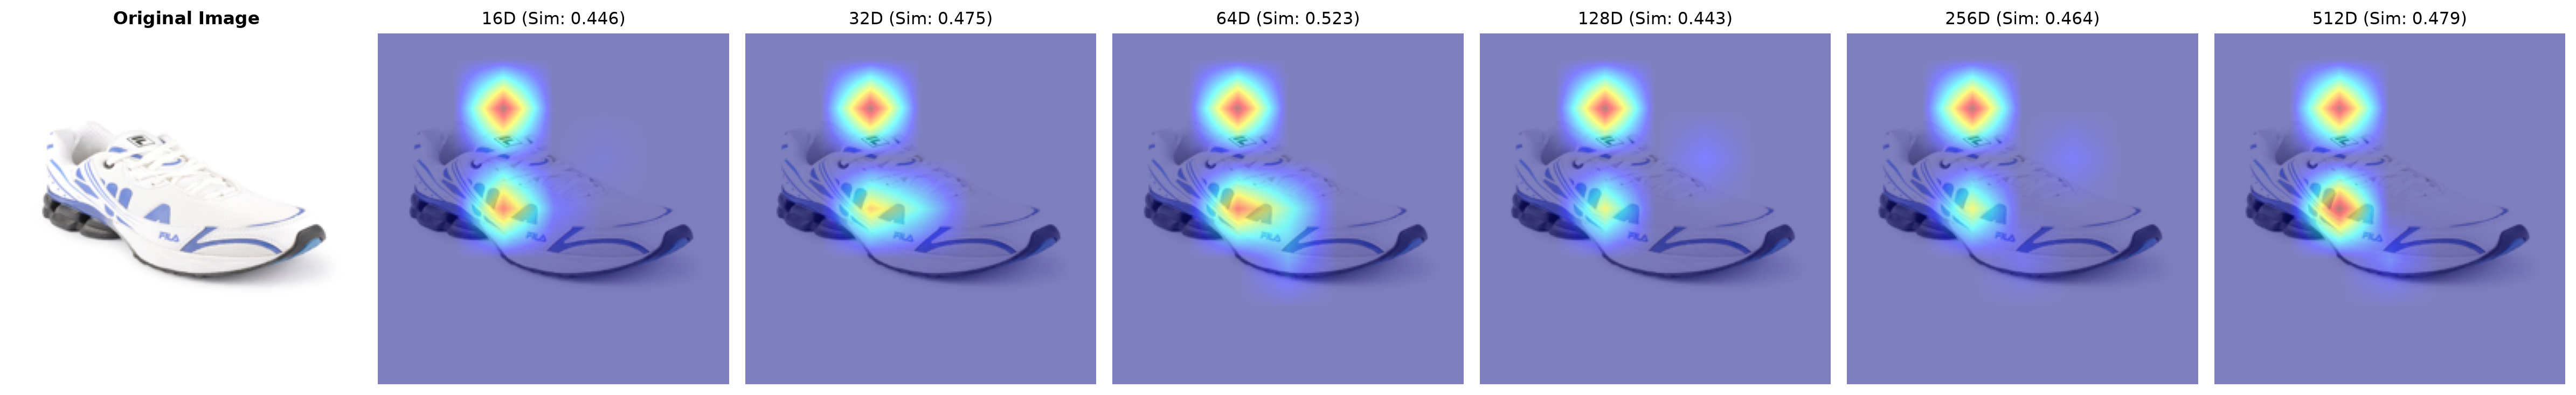

In [16]:
def reshape_transform(tensor, height=7, width=7):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

target_layers = [mrl_model.clip.vision_model.encoder.layers[-1].layer_norm1]
# --------------------------------------------------------

img_tensor = inputs.pixel_values  # shape: [1, 3, 224, 224]

mrl_dims = [16, 32, 64, 128, 256, 512]

fig, axes = plt.subplots(1, len(mrl_dims) + 1, figsize=(24, 4))

axes[0].imshow(rgb_img)
axes[0].axis("off")
axes[0].set_title("Original Image", fontsize=12, fontweight='bold')

for idx, dim in enumerate(mrl_dims):
    txt_embeds_dim = full_text_embeds[:, :dim]
    wrapper = CLIPSimilarityWrapper(mrl_model, txt_embeds_dim, mrl_dim=dim)
    
    # Compute Cosine Similarity Score
    with torch.no_grad():
        score = wrapper(img_tensor).item()
    
    cam = GradCAM(model=wrapper, 
                  target_layers=target_layers, 
                  reshape_transform=reshape_transform)
                  
    grayscale_cam = cam(input_tensor=img_tensor, targets=None)[0]
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    ax = axes[idx + 1]
    ax.imshow(cam_image)
    ax.axis("off")
    ax.set_title(f"{dim}D (Sim: {score:.3f})", fontsize=11)

plt.tight_layout()
plt.show()